In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

x,_ = make_moons(n_samples=100, noise=0.1, random_state=42)
x_scaled = StandardScaler().fit_transform(x)
min_samples = 4

nearest_neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit=nearest_neighbors.fit(x_scaled)
distances, indices = neighbors_fit.kneighbors(x_scaled)
k_distance = np.sort(distances[:, min_samples-1], axis=0)


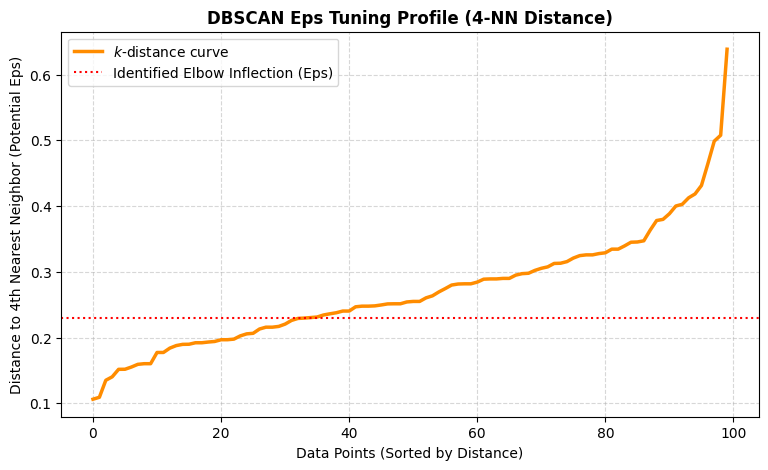

In [5]:
plt.figure(figsize=(9, 5))
plt.plot(k_distance, color='darkorange', linewidth=2.5, label="$k$-distance curve")
plt.title(f"DBSCAN Eps Tuning Profile ({min_samples}-NN Distance)", fontsize=12, fontweight='bold')
plt.xlabel("Data Points (Sorted by Distance)", fontsize=10)
plt.ylabel(f"Distance to {min_samples}th Nearest Neighbor (Potential Eps)", fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)

plt.axhline(y=0.23, color='red', linestyle=':', label="Identified Elbow Inflection (Eps)")
plt.legend()
plt.show()